### Setup

In [1]:
import pm4py
import sys
from pathlib import Path

pm4py.util.constants.SHOW_PROGRESS_BAR = False

ROOT = Path().resolve().parent

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "external"))
sys.path.insert(0, str(ROOT / "external" / "TranslucentActivityRelationships"))

### Generate translucent event logs from event logs

In [3]:
import pickle
from src.pipeline.generate_translucent_logs import generate_translucent_logs

paths = [
    'event_logs/BPIC12 A.xes',
    'event_logs/BPIC12 O.xes',
    'event_logs/BPIC12 W.xes',
    'event_logs/BPIC13 Closed Problems.xes',
    'event_logs/BPIC13 Incidents.xes',
    'event_logs/BPIC13 Open Problems.xes',
    'event_logs/BPIC17 Offer.xes',
    'event_logs/BPIC20 Domestic Declarations.xes',
    'event_logs/BPIC20 International Declarations.xes',
    'event_logs/BPIC20 Prepaid Travel Cost.xes',
    'event_logs/BPIC20 Request For Payment.xes',
    'event_logs/CCC19.xes',
    'event_logs/Helpdesk.xes',
    'event_logs/Hospital Billing.xes',
    'event_logs/RTFM.xes',
    'event_logs/Sepsis.xes',
    'event_logs/WABO Receipt Phase.xes',
    'event_logs/Berlin Parliament Gesetzgebung mb.xes',
    'event_logs/Brandenburg Parliament Gesetzgebung mb.xes',
    'event_logs/Baden Württemberg Parliament Gesetzgebung mb.xes',
]

paths_abs = [str(ROOT / p) for p in paths]

logs = generate_translucent_logs(paths_abs)
with open('logs.pkl', 'wb') as f:
    pickle.dump(logs, f)
print('logs created successfully')

Log Generation:   0%|          | 0/20 [00:00<?, ?it/s]

logs created successfully


In [2]:
import pickle

with open('logs.pkl', 'rb') as f:
    logs = pickle.load(f)

with open('models.pkl', 'rb') as f:
    models = pickle.load(f)

### Compute translucent complexity

*Average-based, Diversity-based, and Dispersion-based Complexity*

In [3]:
from src.pipeline.compute_complexity import compute_complexity

complexity = compute_complexity(logs)
complexity.to_csv('results/complexity.csv', index=False)
print(complexity)

                                            name  complexity_avg_raw  \
0                                       BPIC12 A            3.464563   
1                                       BPIC12 O            2.400000   
2                                       BPIC12 W            1.480183   
3                         BPIC13 Closed Problems            2.343456   
4                               BPIC13 Incidents            2.714286   
5                           BPIC13 Open Problems            3.000000   
6                                   BPIC17 Offer            2.122728   
7                   BPIC20 Domestic Declarations            3.308717   
8              BPIC20 International Declarations            6.041260   
9                     BPIC20 Prepaid Travel Cost            3.460856   
10                    BPIC20 Request For Payment            2.931244   
11                                         CCC19           10.720930   
12                                      Helpdesk            4.87

*Dissimilarity-based Complexity*

In [4]:
from src.pipeline.compute_dissimilarity_complexity import compute_dissimilarity_complexity

diss_complexity = compute_dissimilarity_complexity(logs)
diss_complexity.to_csv('results/diss_complexity.csv', index=False)
print(diss_complexity)

  0%|          | 0/20 [00:00<?, ?it/s]

                                            name  complexity_diss_aa_seq  \
0                                       BPIC12 A                0.272592   
1                                       BPIC12 O                0.251323   
2                                       BPIC12 W                0.163900   
3                         BPIC13 Closed Problems                0.129758   
4                               BPIC13 Incidents                0.254773   
5                           BPIC13 Open Problems                0.000000   
6                                   BPIC17 Offer                0.017867   
7                   BPIC20 Domestic Declarations                0.025240   
8              BPIC20 International Declarations                0.027456   
9                     BPIC20 Prepaid Travel Cost                0.045125   
10                    BPIC20 Request For Payment                0.025881   
11                                         CCC19                0.321125   
12          

### Create Petri nets

In [6]:
from src.pipeline.discover_petri_nets import discover_petri_nets

models = discover_petri_nets(logs)
with open('models.pkl', 'wb') as f:
    pickle.dump(models, f)
print('petri nets created successfully')

petri nets created successfully


### Compute Quality Measures

*Token-based replay approach*

In [5]:
from src.pipeline.compute_model_quality import compute_model_quality

quality = compute_model_quality(models)
quality.to_csv('results/quality.csv', index=False)
print(quality)

  0%|          | 0/20 [00:00<?, ?it/s]

                                            name  precision_imts  \
0                                       BPIC12 A        0.374358   
1                                       BPIC12 O        0.703704   
2                                       BPIC12 W        1.000000   
3                         BPIC13 Closed Problems        0.999162   
4                               BPIC13 Incidents        0.800000   
5                           BPIC13 Open Problems        0.699506   
6                                   BPIC17 Offer        0.924462   
7                   BPIC20 Domestic Declarations        1.000000   
8              BPIC20 International Declarations        0.394234   
9                     BPIC20 Prepaid Travel Cost        1.000000   
10                    BPIC20 Request For Payment        1.000000   
11                                         CCC19        0.615942   
12                                      Helpdesk        0.645309   
13                              Hospital Billing

### Correlate complexity and model quality measurements

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, kendalltau
import warnings
from scipy.stats import ConstantInputWarning

warnings.filterwarnings("ignore", category=ConstantInputWarning)

cpt = complexity.merge(diss_complexity, on='name', how='inner')
merged_df = cpt.merge(quality, on='name', how='inner')
df = merged_df[['complexity_avg_raw_std', 'complexity_avg_norm_std', 'complexity_div_std', 'complexity_disp_std',
           'complexity_diss_aa_seq_std', 'complexity_diss_aa_mset_std',
           'complexity_diss_ac_seq_std', 'complexity_diss_ac_mset_std',
           'f_score_imts', 'f_score_imto', 'f_score_imtf',
           'f_score_imfts', 'f_score_imfto', 'f_score_imftf',
           'precision_imts', 'precision_imto', 'precision_imtf',
           'precision_imfts', 'precision_imfto', 'precision_imftf',
           'fitness_imts', 'fitness_imto', 'fitness_imtf',
           'fitness_imfts', 'fitness_imfto', 'fitness_imftf']]

cols = df.columns
n = len(cols)

pcorr  = pd.DataFrame(index=cols, columns=cols, dtype=float)
ppvals = pd.DataFrame(index=cols, columns=cols, dtype=float)
kcorr  = pd.DataFrame(index=cols, columns=cols, dtype=float)
kpvals = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in range(n):
    for j in range(i, n):
        col1, col2 = cols[i], cols[j]

        if i == j:
            pcorr.iloc[i, j]  = 1.0
            ppvals.iloc[i, j] = np.nan
            kcorr.iloc[i, j]  = 1.0
            kpvals.iloc[i, j] = np.nan
        else:
            mask = df[col1].notna() & df[col2].notna()
            pr, pp = pearsonr(df[col1][mask],  df[col2][mask])
            kt, kp = kendalltau(df[col1][mask], df[col2][mask])

            pcorr.iloc[i, j]  = pcorr.iloc[j, i]  = pr
            ppvals.iloc[i, j] = ppvals.iloc[j, i] = pp
            kcorr.iloc[i, j]  = kcorr.iloc[j, i]  = kt
            kpvals.iloc[i, j] = kpvals.iloc[j, i] = kp

pcorr.to_csv('results/pcorr.csv')
kcorr.to_csv('results/kcorr.csv')
ppvals.to_csv('results/ppvals.csv')
kpvals.to_csv('results/kpvals.csv')

### Visualizations

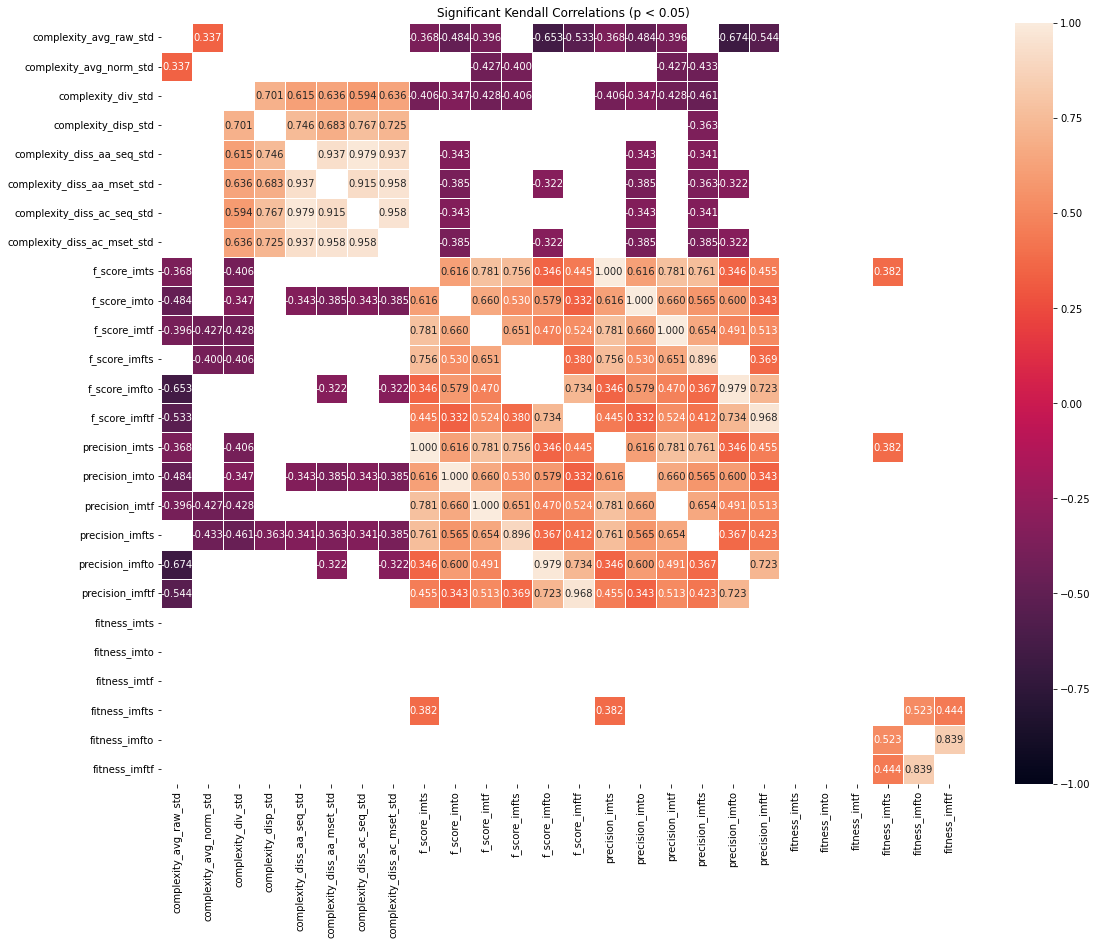

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

alpha = 0.05

kcorr_sig = kcorr.where(kpvals < alpha)

plt.figure(figsize=(18, 14))

sns.heatmap(
    kcorr_sig,
    annot=True,
    fmt=".3f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Significant Kendall Correlations (p < 0.05)")
plt.show()

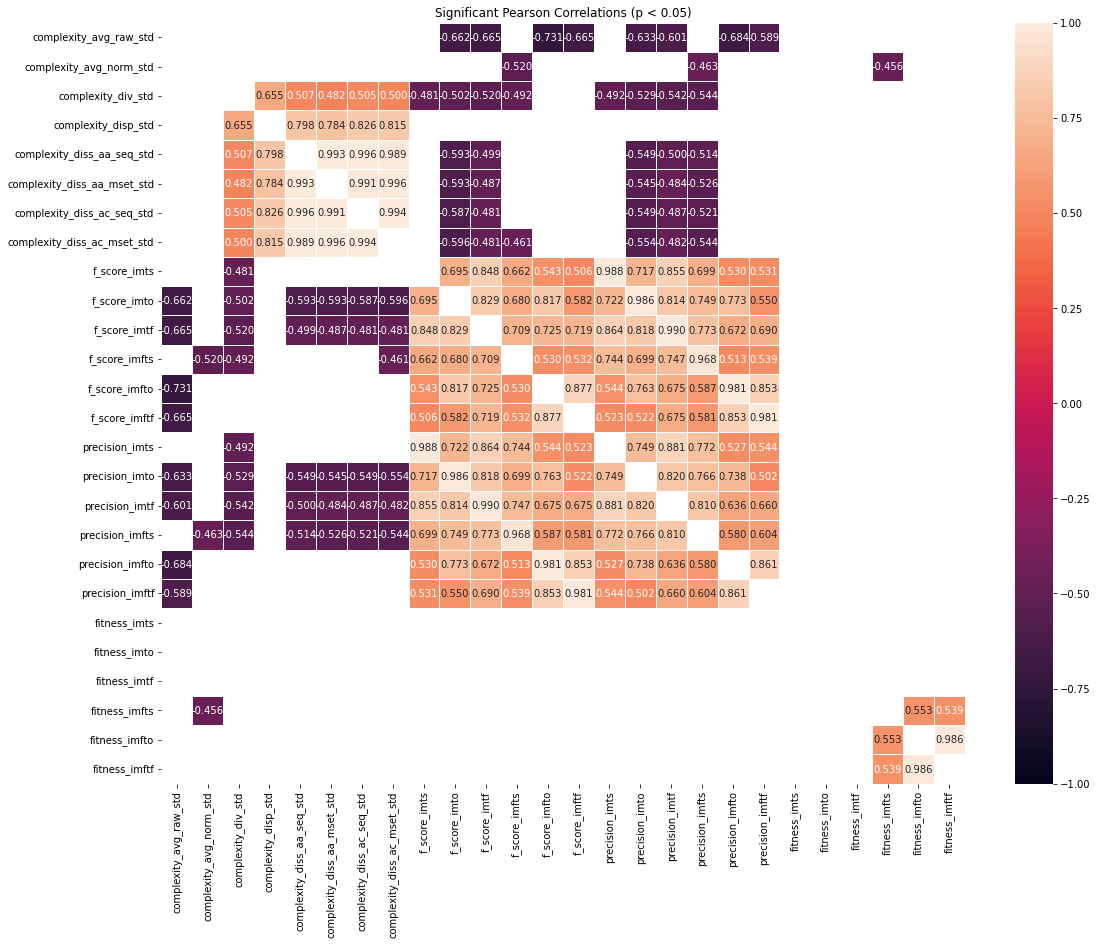

In [20]:
import seaborn as sns

alpha = 0.05

pcorr_sig = pcorr.where(ppvals < alpha)

plt.figure(figsize=(18, 14))

sns.heatmap(
    pcorr_sig,
    annot=True,
    fmt=".3f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Significant Pearson Correlations (p < 0.05)")
plt.show()

In [12]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

os.makedirs('results', exist_ok=True)

targets = [
    'f_score_imts', 'f_score_imto', 'f_score_imtf',
    'f_score_imfts', 'f_score_imfto', 'f_score_imftf',
]

def run_ols(df, predictors, target):
    """Fit a multiple linear regression for a single quality target."""
    sub = df[predictors + [target]].dropna()
    X = sm.add_constant(sub[predictors])
    y = sub[target]
    model = sm.OLS(y, X).fit()
    return model, sub

def vif_table(df, predictors):
    """Variance inflation factor per predictor (>5 indicates collinearity, >10 severe)."""
    sub = df[predictors].dropna()
    X = sm.add_constant(sub).values
    cols = ['const'] + predictors
    vifs = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return pd.DataFrame({'variable': cols, 'VIF': vifs}).iloc[1:]  # drop const

In [13]:
reduced = [
    'complexity_avg_norm_std', # absolute size of enabled activities
    'complexity_avg_raw_std', # relative size of enabled activities
    'complexity_div_std', # diversity of enabled activities
    'complexity_disp_std', # nonsemantical variability of enabled activities
    'complexity_diss_aa_seq_std', # semantical variability of enabled activities
]
print("\n=== Reduced OLS model (5 predictors) ===")
print("VIF:")
print(vif_table(df, reduced).to_string(index=False))


=== Reduced OLS model (5 predictors) ===
VIF:
                  variable      VIF
   complexity_avg_norm_std 1.074855
    complexity_avg_raw_std 2.458995
        complexity_div_std 1.988236
       complexity_disp_std 8.110587
complexity_diss_aa_seq_std 5.940136


In [16]:
reduced = [
    'complexity_avg_raw_std', # relative size of enabled activities
    'complexity_div_std', # diversity of enabled activities
    'complexity_diss_aa_seq_std', # semantical variability of enabled activities
]
print("\n=== Reduced OLS model (3 predictors) ===")
print("VIF:")
print(vif_table(df, reduced).to_string(index=False))
for tgt in targets:
    model, sub = run_ols(df, reduced, tgt)
    print(f"\n--- {tgt} ---")
    print(model.summary().tables[1])   # coefficient table (coef, std err, t, p, CI)
    print(f"n={int(model.nobs)}  R2={model.rsquared:.3f}  "
          f"adj.R2={model.rsquared_adj:.3f}  F p={model.f_pvalue:.4f}")


=== Reduced OLS model (3 predictors) ===
VIF:
                  variable      VIF
    complexity_avg_raw_std 1.071058
        complexity_div_std 1.366493
complexity_diss_aa_seq_std 1.441829

--- f_score_imts ---
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.8445      0.034     24.675      0.000       0.772       0.917
complexity_avg_raw_std        -0.0799      0.035     -2.257      0.038      -0.155      -0.005
complexity_div_std            -0.0938      0.040     -2.346      0.032      -0.179      -0.009
complexity_diss_aa_seq_std     0.0171      0.041      0.417      0.682      -0.070       0.104
n=20  R2=0.418  adj.R2=0.309  F p=0.0305

--- f_score_imto ---
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

### LOOCV for simplified regression model

In [17]:
from statsmodels.stats.outliers_influence import OLSInfluence

reduced = [
    'complexity_avg_raw_std', # relative size of enabled activities
    'complexity_div_std', # diversity of enabled activities
    'complexity_diss_aa_seq_std', # semantical variability of enabled activities
]

def loocv_report(df, predictors, target):
    model, sub = run_ols(df, predictors, target)
    infl = model.get_influence()

    h         = infl.hat_matrix_diag      
    loo_resid = infl.resid_press          
    y         = sub[target].values
    n, p      = int(model.nobs), model.df_model + 1

    press  = float((loo_resid ** 2).sum())
    sst    = float(((y - y.mean()) ** 2).sum())
    q2     = 1 - press / sst               
    rmse   = np.sqrt(press / n)
    mae    = np.abs(loo_resid).mean()
    y_hat  = y - loo_resid                 

    return {
        'target':   target,
        'n':        n,
        'R2_in':    model.rsquared,
        'adjR2_in': model.rsquared_adj,
        'Q2':       q2,
        'RMSE_cv':  rmse,
        'MAE_cv':   mae,
        'PRESS':    press,
    }, sub, y, y_hat, h, loo_resid, p


def coef_stability(df, predictors, target):
    _, sub = run_ols(df, predictors, target)
    X, y = sm.add_constant(sub[predictors]), sub[target]
    full = sm.OLS(y, X).fit().params
    loo  = pd.DataFrame(
        [sm.OLS(y.drop(y.index[i]), X.drop(X.index[i])).fit().params
         for i in range(len(sub))]
    )
    return pd.DataFrame({
        'full':       full,
        'loo_min':    loo.min(),
        'loo_max':    loo.max(),
        'loo_std':    loo.std(),
        'sign_flips': (np.sign(loo) != np.sign(full)).sum(),
    })

print("\n=== LOOCV (reduced 3-predictor model) ===")
summary_rows = []
for tgt in targets:
    metrics, sub, y, y_hat, h, loo_resid, p = loocv_report(df, reduced, tgt)
    summary_rows.append(metrics)

    thr = 2 * p / metrics['n']
    flagged = sub.index[h > thr].tolist()

    print(f"\n--- {tgt} ---")
    print(f"R2_in={metrics['R2_in']:.3f}  Q2={metrics['Q2']:.3f}  "
          f"RMSE_cv={metrics['RMSE_cv']:.3f}  MAE_cv={metrics['MAE_cv']:.3f}")
    if flagged:
        print(f"  high-leverage (h>{thr:.2f}): {flagged}")

    pd.DataFrame({'observed': y, 'loo_pred': y_hat, 'leverage': h},
                 index=sub.index).to_csv(f'results/loocv_{tgt}.csv')

summary = pd.DataFrame(summary_rows).set_index('target').round(3)
print("\n=== LOOCV summary (all targets) ===")
print(summary.to_string())
summary.to_csv('results/loocv_summary.csv')


=== LOOCV (reduced 3-predictor model) ===

--- f_score_imts ---
R2_in=0.418  Q2=-0.220  RMSE_cv=0.198  MAE_cv=0.156
  high-leverage (h>0.40): [11, 15]

--- f_score_imto ---
R2_in=0.734  Q2=0.620  RMSE_cv=0.168  MAE_cv=0.128
  high-leverage (h>0.40): [11, 15]

--- f_score_imtf ---
R2_in=0.714  Q2=0.520  RMSE_cv=0.155  MAE_cv=0.123
  high-leverage (h>0.40): [11, 15]

--- f_score_imfts ---
R2_in=0.388  Q2=0.085  RMSE_cv=0.105  MAE_cv=0.087
  high-leverage (h>0.40): [11, 15]

--- f_score_imfto ---
R2_in=0.646  Q2=0.467  RMSE_cv=0.169  MAE_cv=0.143
  high-leverage (h>0.40): [11, 15]

--- f_score_imftf ---
R2_in=0.501  Q2=0.003  RMSE_cv=0.207  MAE_cv=0.153
  high-leverage (h>0.40): [11, 15]

=== LOOCV summary (all targets) ===
                n  R2_in  adjR2_in     Q2  RMSE_cv  MAE_cv  PRESS
target                                                           
f_score_imts   20  0.418     0.309 -0.220    0.198   0.156  0.785
f_score_imto   20  0.734     0.684  0.620    0.168   0.128  0.564
f_sc